# Projet 10 — UOI Games | Phase 3 : Segmentation chiffrée & questionnaire

**Objectif :** identifier, à partir des données du catalogue (PJ1, 440 896 jeux, 2000-2020) et des tendances marché (Phase 2), un ou plusieurs segments de clientèle candidats — puis construire un questionnaire pour tester ces hypothèses auprès de vrais répondants (min. 5 questions / 10 personnes, demandé par Juliette).

**Important — ce que ces données peuvent dire et ce qu'elles ne peuvent pas dire :**
PJ1 ne contient aucune donnée démographique sur les joueurs eux-mêmes (pas d'âge, pas de genre du joueur). Les indicateurs mobilisés ici (`rating`, `ratings_count`, `playtime`, `esrb_rating`) sont donc des **proxys d'engagement et de cible d'âge légale**, pas des données déclaratives sur qui joue réellement. C'est précisément le rôle du questionnaire (section 3) de combler ce manque avec de vraies données déclaratives.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

pd.set_option('display.max_columns', 30)
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 10

df = pd.read_csv('data/catalog_clean.csv', low_memory=False)
print('Catalogue chargé :', df.shape)


Catalogue chargé : (440896, 71)


## 1. Quel(s) genre(s) et quelle(s) plateforme(s) concentrent le plus d'engagement ?

In [2]:
console_cols = ['PlayStation 4','Xbox One','Nintendo Switch','PlayStation 3','Xbox 36','Wii U',
                'PS Vita','Nintendo 3DS','PlayStation 5','Xbox Series S/X','PlayStation','PSP',
                'Nintendo DS','Xbox','GameCube','Wii']
pc_cols = ['PC','macOS','Linux']
mobile_cols = ['Android','iOS']
console_cols = [c for c in console_cols if c in df.columns]

df['is_console'] = (df[console_cols].sum(axis=1) > 0).astype(int)
df['is_pc'] = (df[pc_cols].sum(axis=1) > 0).astype(int)
df['is_mobile'] = (df[mobile_cols].sum(axis=1) > 0).astype(int)

top_genres = ['Action','Adventure','RPG','Shooter','Strategy','Simulation','Sports','Racing']
rows = []
for g in top_genres:
    sub = df[df['genre_principal'] == g]
    rows.append({
        'genre': g, 'nb_jeux': len(sub),
        'pct_console': round(sub['is_console'].mean()*100, 1),
        'pct_pc': round(sub['is_pc'].mean()*100, 1),
        'pct_mobile': round(sub['is_mobile'].mean()*100, 1),
        'rating_moyen': round(sub['rating'].mean(), 2),
        'playtime_moyen': round(sub['playtime'].mean(), 2),
    })
genre_platform = pd.DataFrame(rows).sort_values('nb_jeux', ascending=False)
genre_platform


,genre,nb_jeux,pct_console,pct_pc,pct_mobile,rating_moyen,playtime_moyen
0,Action,94066,6.8,63.4,21.3,0.18,0.38
1,Adventure,51333,3.0,64.9,21.0,0.10,0.33
5,Simulation,24500,2.1,53.4,31.4,0.05,0.23
3,Shooter,21833,1.2,73.3,3.3,0.02,0.02
4,Strategy,21616,2.6,61.8,27.9,0.14,0.47
2,RPG,16753,4.8,61.8,26.7,0.15,0.49
6,Sports,7851,10.6,37.8,45.4,0.13,0.34
7,Racing,6311,7.7,52.3,31.4,0.10,0.18


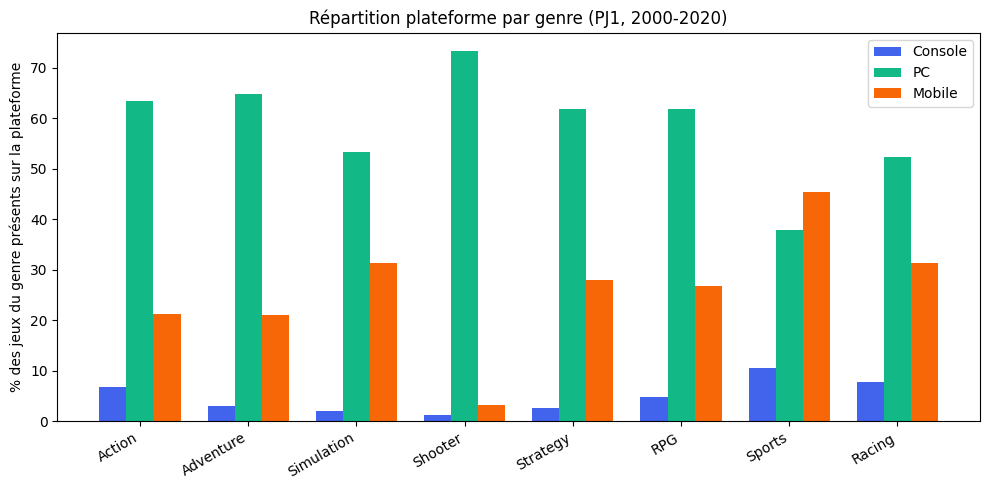


Lecture : le catalogue est dominé par le PC (long tail d'indépendants), ce qui écrase
mécaniquement le poids relatif des consoles dans TOUS les genres. Le signal utile n'est
donc pas le % absolu mais le RANG relatif entre genres : le genre Sports se distingue
avec la plus forte part console (10,6%), cohérent avec le poids réel des franchises
sportives (FIFA, Madden...) sur consoles de salon.



In [3]:
fig, ax = plt.subplots(figsize=(10,5))
x = np.arange(len(genre_platform))
w = 0.25
ax.bar(x-w, genre_platform['pct_console'], width=w, label='Console', color='#4263EB')
ax.bar(x, genre_platform['pct_pc'], width=w, label='PC', color='#12B886')
ax.bar(x+w, genre_platform['pct_mobile'], width=w, label='Mobile', color='#F76707')
ax.set_xticks(x)
ax.set_xticklabels(genre_platform['genre'], rotation=30, ha='right')
ax.set_ylabel('% des jeux du genre présents sur la plateforme')
ax.set_title('Répartition plateforme par genre (PJ1, 2000-2020)')
ax.legend()
plt.tight_layout()
plt.savefig('data/fig_genre_x_plateforme.png', dpi=120)
plt.show()

print('''
Lecture : le catalogue est dominé par le PC (long tail d\'indépendants), ce qui écrase
mécaniquement le poids relatif des consoles dans TOUS les genres. Le signal utile n\'est
donc pas le % absolu mais le RANG relatif entre genres : le genre Sports se distingue
avec la plus forte part console (10,6%), cohérent avec le poids réel des franchises
sportives (FIFA, Madden...) sur consoles de salon.
''')


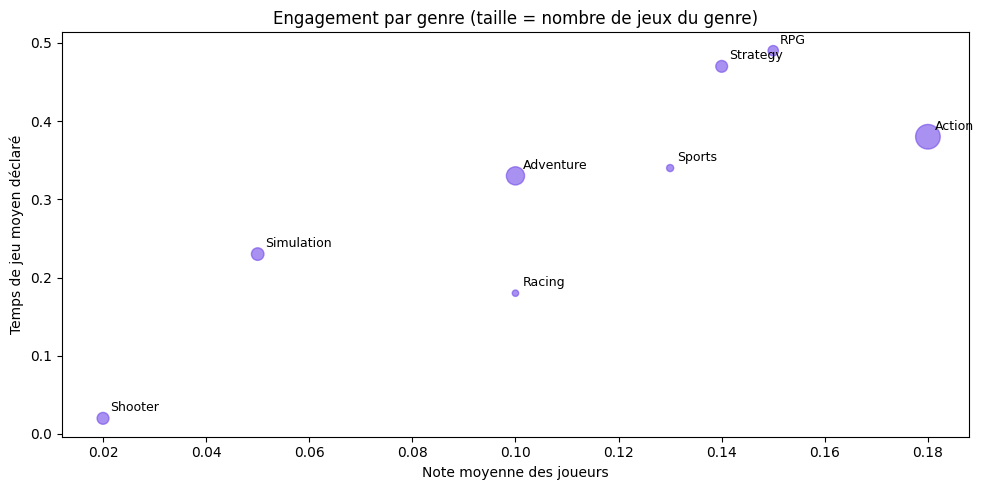

In [4]:
fig, ax = plt.subplots()
ax.scatter(genre_platform['rating_moyen'], genre_platform['playtime_moyen'], s=genre_platform['nb_jeux']/300, alpha=0.6, color='#7048E8')
for _, row in genre_platform.iterrows():
    ax.annotate(row['genre'], (row['rating_moyen'], row['playtime_moyen']), fontsize=9, xytext=(5,5), textcoords='offset points')
ax.set_xlabel('Note moyenne des joueurs')
ax.set_ylabel('Temps de jeu moyen déclaré')
ax.set_title('Engagement par genre (taille = nombre de jeux du genre)')
plt.tight_layout()
plt.savefig('data/fig_engagement_genres.png', dpi=120)
plt.show()


## 2. Quel est le profil d'âge légal (ESRB) des genres les plus engageants ?

Rappel de prudence : seuls 12% des jeux du catalogue ont un `esrb_rating` renseigné. Les pourcentages ci-dessous portent uniquement sur le sous-ensemble renseigné pour chaque genre — à interpréter comme une tendance, pas une mesure exhaustive.


In [5]:
esrb_order = ['Everyone', 'Everyone 10+', 'Teen', 'Mature', 'Adults Only', 'Rating Pending']
rows = []
for g in top_genres:
    sub = df[(df['genre_principal']==g) & (df['esrb_rating'].notna())]
    if len(sub) < 20:
        continue
    pct = (sub['esrb_rating'].value_counts(normalize=True)*100).reindex(esrb_order).fillna(0)
    pct.name = g
    rows.append(pct)

esrb_tab = pd.DataFrame(rows).round(1)
esrb_tab


esrb_rating,Everyone,Everyone 10+,Teen,Mature,Adults Only,Rating Pending
Action,4.5,50.5,25.2,18.6,1.1,0.1
Adventure,3.7,68.2,20.7,6.3,1.0,0.1
RPG,1.6,59.6,29.0,9.2,0.5,0.1
Shooter,6.8,31.7,29.3,28.3,3.4,0.5
Strategy,4.4,75.1,16.4,3.8,0.3,0.0
Simulation,3.9,81.2,11.1,3.2,0.5,0.0
Sports,8.1,81.0,7.9,3.0,0.0,0.1
Racing,5.8,84.4,8.6,1.1,0.0,0.1


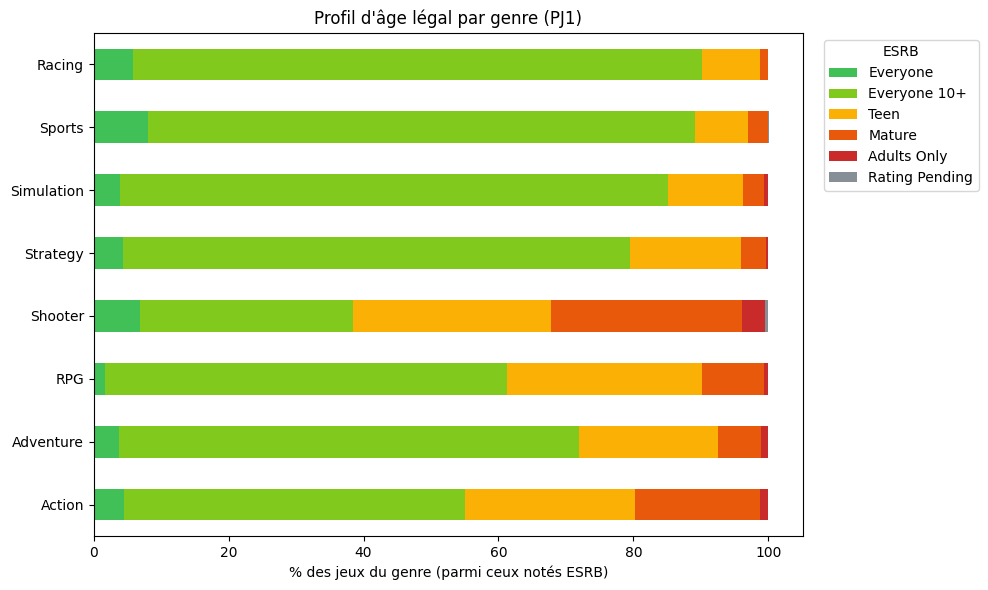


Constat clé : Action et Shooter sont les genres les plus orientés Mature/Teen
(cible adulte/adolescent avancé). À l'inverse, Strategy, Simulation, Sports et
Racing sont massivement classés Everyone / Everyone 10+ (cible familiale/tout public).



In [6]:
fig, ax = plt.subplots(figsize=(10,6))
esrb_tab[esrb_order].plot(kind='barh', stacked=True, ax=ax,
    color=['#40C057','#82C91E','#FAB005','#E8590C','#C92A2A','#868E96'])
ax.set_xlabel('% des jeux du genre (parmi ceux notés ESRB)')
ax.set_title('Profil d\'âge légal par genre (PJ1)')
ax.legend(title='ESRB', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig('data/fig_esrb_par_genre.png', dpi=120)
plt.show()

print('''
Constat clé : Action et Shooter sont les genres les plus orientés Mature/Teen
(cible adulte/adolescent avancé). À l\'inverse, Strategy, Simulation, Sports et
Racing sont massivement classés Everyone / Everyone 10+ (cible familiale/tout public).
''')


## 3. Deux segments candidats à tester

En croisant ces constats avec la Phase 2 (joueur moyen vieilli à 37-40 ans, quasi-parité H/F, pratique cross-générationnelle, 81% des parents jouant avec leurs enfants, genres Action/Sport/Shooter dominants en ventes historiques), deux segments se dégagent comme candidats crédibles pour un premier titre AAA UOI Games :

### Segment A — « Cœur de cible engagé »
- **Genres :** Action / RPG (éventuellement teinté Shooter)
- **Classification :** Teen à Mature
- **Plateformes :** Console (PS/Xbox nouvelle génération) + PC
- **Profil visé :** joueurs 20-40 ans, engagement fort (playtime et note les plus élevés du catalogue), habitués des franchises AAA existantes
- **Argument pour :** c'est le segment le plus vaste en volume et en ventes historiques (Action = 1er genre sur PJ1 et PJ2) — marché prouvé
- **Risque :** c'est aussi le segment le plus saturé de concurrence AAA établie (cf. SWOT/PESTEL Phase 2)

### Segment B — « Famille / multi-générationnel »
- **Genres :** Sports / Simulation / Racing
- **Classification :** Everyone à Everyone 10+
- **Plateformes :** Console en priorité (part console relative la plus élevée, notamment Sports)
- **Profil visé :** joueurs 30-55 ans jouant seuls ou en co-play avec enfants/famille, aligné avec le vieillissement du joueur moyen (40 ans en France) et les 81% de parents jouant avec leurs enfants (ESA 2026)
- **Argument pour :** moins saturé en offre AAA pure (dominé par quelques franchises sportives annuelles), différenciation possible avec une nouvelle IP orientée simulation/aventure familiale
- **Risque :** taille de marché plus incertaine pour un tout premier titre AAA, moins de données de vente historiques dans PJ2 pour ce type de profil

**Le questionnaire ci-dessous est conçu pour arbitrer entre A et B (ou révéler un segment hybride), avec des questions permettant ensuite des tests de corrélation (Phase 4) entre âge, plateforme, genre préféré et intention d'achat.**


## 4. Questionnaire consommateurs — à déployer sur Google Forms / SurveyMonkey

**Cible :** minimum 10 répondants (demande de Juliette), idéalement 25-30+ pour des tests de corrélation plus robustes en Phase 4. Diffusion suggérée : réseaux personnels/professionnels, groupes gaming (Discord, Reddit, forums), panel OpenClassrooms si autorisé.

**10 questions proposées (au-delà du minimum de 5 demandé) :**

| # | Question | Type | Objectif analytique |
|---|---|---|---|
| 1 | Quelle est votre tranche d'âge ? (moins de 18 / 18-24 / 25-34 / 35-44 / 45-54 / 55+) | Choix unique | Variable de segmentation démographique |
| 2 | Sur quelle(s) plateforme(s) jouez-vous le plus souvent ? (PC / PlayStation / Xbox / Nintendo Switch / Mobile) | Choix multiple | Tester le poids réel des plateformes vs Segment A/B |
| 3 | Quels genres de jeux vidéo préférez-vous ? (Action, Aventure, RPG, Shooter, Sport, Simulation, Stratégie, Course, Autre) | Choix multiple | Confronter les préférences déclarées aux données PJ1/PJ2 |
| 4 | À quelle fréquence jouez-vous aux jeux vidéo ? (Tous les jours / Plusieurs fois/semaine / Occasionnellement / Rarement) | Choix unique | Proxy d'engagement, à croiser avec l'âge et le genre |
| 5 | Jouez-vous parfois en famille ou avec vos enfants ? (Oui souvent / Parfois / Jamais / Sans objet) | Choix unique | Teste directement l'hypothèse du Segment B (co-play familial) |
| 6 | Combien dépensez-vous en moyenne par mois pour les jeux vidéo (achats, abonnements, DLC) ? (0€ / 1-20€ / 21-50€ / 51-100€ / 100€+) | Choix unique | Variable de valeur économique du segment |
| 7 | Êtes-vous plus enclin à acheter un jeu appartenant à une licence connue, ou êtes-vous ouvert(e) à une toute nouvelle licence si le concept vous plaît ? (Licence connue uniquement / Plutôt licence connue / Indifférent / Plutôt nouvelle licence / Peu importe si le concept est bon) | Échelle | Teste le risque "nouvelle IP" identifié en SWOT (faiblesse UOI Games) |
| 8 | Quel est votre avis sur les achats intégrés aléatoires (type "loot box") dans un jeu payant ? (Très négatif / Négatif / Neutre / Positif si transparent sur les probabilités / Peu importe) | Échelle | Alimente le volet Légal du PESTEL (Digital Fairness Act) et le modèle économique recommandé |
| 9 | Qu'est-ce qui vous ferait le plus essayer un nouveau jeu vidéo AAA ? (Univers/histoire originale / Qualité graphique / Recommandation d'un proche ou streamer / Multijoueur avec des amis / Prix) | Choix unique | Alimente les recommandations marketing/écosystème (Phase 5) |
| 10 | (Optionnel) Un mot sur le type de jeu vidéo que vous aimeriez voir sortir et qui n'existe pas encore selon vous ? | Texte libre | Source d'inspiration qualitative pour le concept de jeu (Phase 5) |

**Note méthodologique pour la Phase 4 :** les questions 1, 2, 3, 5 et 6 sont conçues pour permettre des tests de corrélation (ex. Chi²/V de Cramér entre âge et genre préféré, entre co-play familial et genre Sport/Simulation, entre plateforme et budget mensuel) qui viendront confirmer ou infirmer les hypothèses des Segments A et B.


## 5. Synthèse & prochaine étape

**Ce qui est fait :**
- Segmentation quantitative par genre/plateforme/classification d'âge à partir des données réelles du catalogue
- Deux segments candidats formulés et argumentés (A : cœur de cible Action/RPG ; B : famille Sport/Simulation)
- Questionnaire de 10 questions prêt à être mis en ligne (Google Forms/SurveyMonkey)

**Ce qu'il reste à faire avant la Phase 4 :**
- Déployer le questionnaire et collecter au moins 10 réponses (action à mener par vos soins — je peux vous aider à formuler l'invitation de diffusion si besoin)
- Une fois les réponses collectées, me les transmettre (export CSV Google Forms/SurveyMonkey) pour lancer la Phase 4 : tests de corrélation et confirmation du segment retenu
